<a href="https://colab.research.google.com/github/Zeyadd106/project-image/blob/main/FireDataKaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Forest Fire, Smoke & Non-Fire Detection — Deep Learning Project

**Dataset:** [Forest Fire, Smoke and Non-Fire Image Dataset](https://www.kaggle.com/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset)

**Classes:**
- 🔥 `Fire` — Images containing forest fire
- 💨 `Smoke` — Images containing smoke
- ✅ `Non-fire` — Normal forest images

**Project Steps:**
1. Install & Download Dataset
2. Explore & Visualize Dataset
3. Image Analysis (Histogram, Brightness, Contrast)
4. Data Preprocessing & Augmentation
5. Build CNN Model from Scratch
6. Train CNN Model
7. Plot Training Curves
8. Evaluate CNN (Metrics + Confusion Matrix)
9. Build ResNet50 Transfer Learning Model
10. Train ResNet50 (Phase 1 + Phase 2 Fine-tuning)
11. Evaluate ResNet50
12. Compare Both Models
13. Save Model & Predict New Images

# **📦 Install Dependencies & Download Dataset**

In [ ]:
!pip install kaggle -q

import os
os.environ['KAGGLE_USERNAME'] = "Mariammuhamed"
os.environ['KAGGLE_KEY']      = "71e67b17e1c402a1f2de85c4a5537abe"

!kaggle datasets download -d amerzishminha/forest-fire-smoke-and-non-fire-image-dataset
!unzip -o -q forest-fire-smoke-and-non-fire-image-dataset.zip -d forest_dataset
print("✅ Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset
License(s): CC0-1.0
forest-fire-smoke-and-non-fire-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Dataset downloaded and extracted!


### **📚 Import Libraries**


In [ ]:
import os, pathlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

BASE_DIR  = pathlib.Path("forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR  = BASE_DIR / "test"

IMG_SIZE   = 64
BATCH_SIZE = 32
EPOCHS     = 10
CLASSES    = ["fire", "non fire", "Smoke"]

### 🗂️ **Explore** Dataset Structure

In [ ]:
# Count images per class
print("📊 Dataset distribution:\n")
for split in ["train", "test"]:
    print(f"  [{split.upper()}]")
    split_dir = BASE_DIR / split
    for cls in CLASSES:
        cls_dir = split_dir / cls
        n = len(list(cls_dir.glob("*.*")))
        bar = "█" * (n // 400)
        print(f"    {cls:<10}  {n:>5} images  {bar}")
    print()

📊 Dataset distribution:

  [TRAIN]
    fire        10800 images  ███████████████████████████
    non fire    10800 images  ███████████████████████████
    Smoke       10800 images  ███████████████████████████

  [TEST]
    fire         3500 images  ████████
    non fire     3500 images  ████████
    Smoke        3500 images  ████████



#Preprocessing (Shared for both models)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PREPROCESSING  (Shared for both models)
# ═══════════════════════════════════════════════════════════════

# ── 1. Handle missing / corrupted images ────────────────────────
import imghdr

def check_images(root_dir):
    """Scan all images; print path of any that are corrupt or unreadable."""
    bad = []
    for img_path in pathlib.Path(root_dir).rglob('*.*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}:
            continue
        try:
            kind = imghdr.what(str(img_path))
            if kind is None:
                bad.append(str(img_path))
        except Exception:
            bad.append(str(img_path))
    return bad

print('🔍 Checking for corrupted images ...')
bad_files = check_images(BASE_DIR)
if bad_files:
    print(f'  ⚠️  Found {len(bad_files)} bad file(s):')
    for f in bad_files[:10]:
        print('    ', f)
else:
    print('  ✅ No corrupted images found.')

# ── 2. Check class balance ──────────────────────────────────────
print('\n📊 Class balance check (TRAIN):')
counts = {}
for cls in CLASSES:
    n = len(list((TRAIN_DIR / cls).glob('*.*')))
    counts[cls] = n
    print(f'  {cls:<10} : {n} images')

max_cls = max(counts, key=counts.get)
min_cls = min(counts, key=counts.get)
ratio   = counts[max_cls] / counts[min_cls]
if ratio > 1.5:
    print(f'\n  ⚠️  Class imbalance detected (ratio {ratio:.1f}x).')
    print('  → Addressed with class_weight in model.fit() and augmentation.')
else:
    print('\n  ✅ Classes are reasonably balanced.')

# Compute class weights for imbalance correction
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

all_labels = []
for i, cls in enumerate(CLASSES):
    n = counts[cls]
    all_labels.extend([i] * n)
all_labels = np.array(all_labels)

weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weight_dict = dict(enumerate(weights))
print('\nClass weights:', {CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})

# ── 3. Train / Validation / Test split  (70 / 15 / 15) ──────────
# The dataset already provides a train/ and test/ folder.
# We carve out 15% of train as a validation set using validation_split.
VAL_SPLIT = 0.15   # 15% of train → validation

# ── 4. Training generator  ──────────────────────────────────────
#    Resize       → target_size=(IMG_SIZE, IMG_SIZE)  [224×224 equivalent]
#    Normalize    → rescale=1/255  maps pixels to [0, 1]
#    Augmentation → rotation, flip, zoom, brightness, contrast
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,          # Normalize to [0, 1]
    rotation_range     = 15,                 # Random rotation ±15°
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,               # Random horizontal flip
    zoom_range         = 0.1,                # Random zoom
    brightness_range   = [0.7, 1.3],         # Brightness adjustment
    # Contrast is handled via channel_shift_range (simulates contrast change)
    channel_shift_range= 20.0,               # Contrast-like color jitter
    validation_split   = VAL_SPLIT           # 15% → validation
)

# ── 5. Validation & Test generators (ONLY rescale, no augmentation) ─
val_datagen  = ImageDataGenerator(rescale=1.0 / 255, validation_split=VAL_SPLIT)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    classes      = CLASSES,
    subset       = 'training',               # 70% of train folder
    shuffle      = True,
    seed         = 42
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    classes      = CLASSES,
    subset       = 'validation',             # 15% of train folder
    shuffle      = False,
    seed         = 42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    classes      = CLASSES,
    shuffle      = False
)

print('\n✅ Data generators ready.')
print(f'   Train batches : {len(train_gen)}')
print(f'   Val   batches : {len(val_gen)}')
print(f'   Test  batches : {len(test_gen)}')
print('   Class indices :', train_gen.class_indices)


🔍 Checking for corrupted images ...
  ⚠️  Found 49 bad file(s):
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (6698).jpg
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (113).jpg
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (59).png
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (10).jpg
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (112).jpg
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (96).jpg
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (82).png
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (308).png
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (6759).jpg
     forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/non fire/Non_Fire (258).png

📊 Class

In [ ]:
import cv2

# Load one sample fire image for demonstration
sample_path = str(next((TRAIN_DIR / "fire").glob("*.*")))
img = cv2.imread(sample_path)

print("✅ Image loaded:", sample_path)
print("   Shape:", img.shape)

✅ Image loaded: forest_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/fire/Fire (2427).jpg
   Shape: (250, 250, 3)


# **Brightness & Contrast**

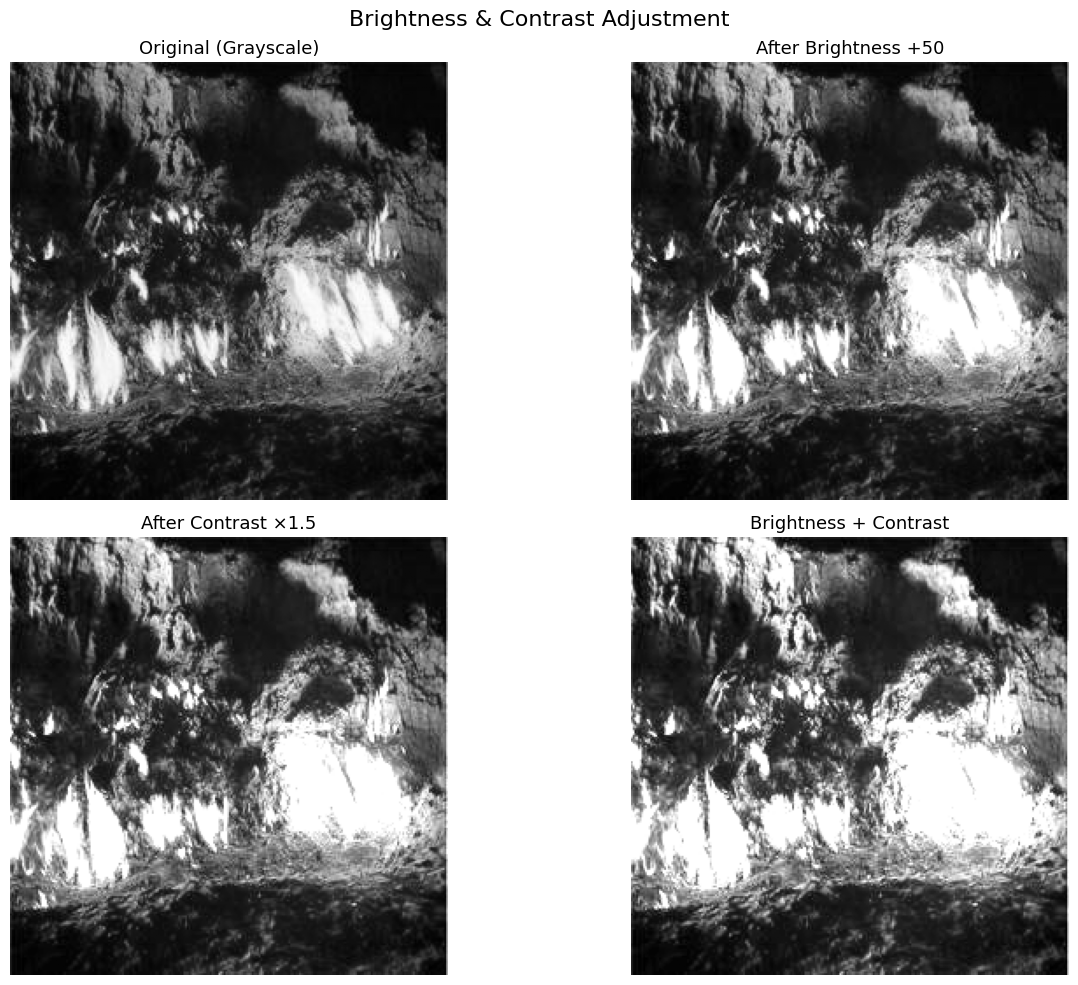

In [ ]:
# --- Brightness & Contrast Adjustment ---
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

bright   = cv2.convertScaleAbs(img_gray, alpha=1,   beta=50)
contrast = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=0)
both     = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("Original (Grayscale)", fontsize=13)
axes[0, 0].axis('off')

axes[0, 1].imshow(bright, cmap='gray')
axes[0, 1].set_title("After Brightness +50", fontsize=13)
axes[0, 1].axis('off')

axes[1, 0].imshow(contrast, cmap='gray')
axes[1, 0].set_title("After Contrast ×1.5", fontsize=13)
axes[1, 0].axis('off')

axes[1, 1].imshow(both, cmap='gray')
axes[1, 1].set_title("Brightness + Contrast", fontsize=13)
axes[1, 1].axis('off')

plt.suptitle("Brightness & Contrast Adjustment", fontsize=16)
plt.tight_layout()
plt.show()

# Histogram Comparison Before & After Adjustments

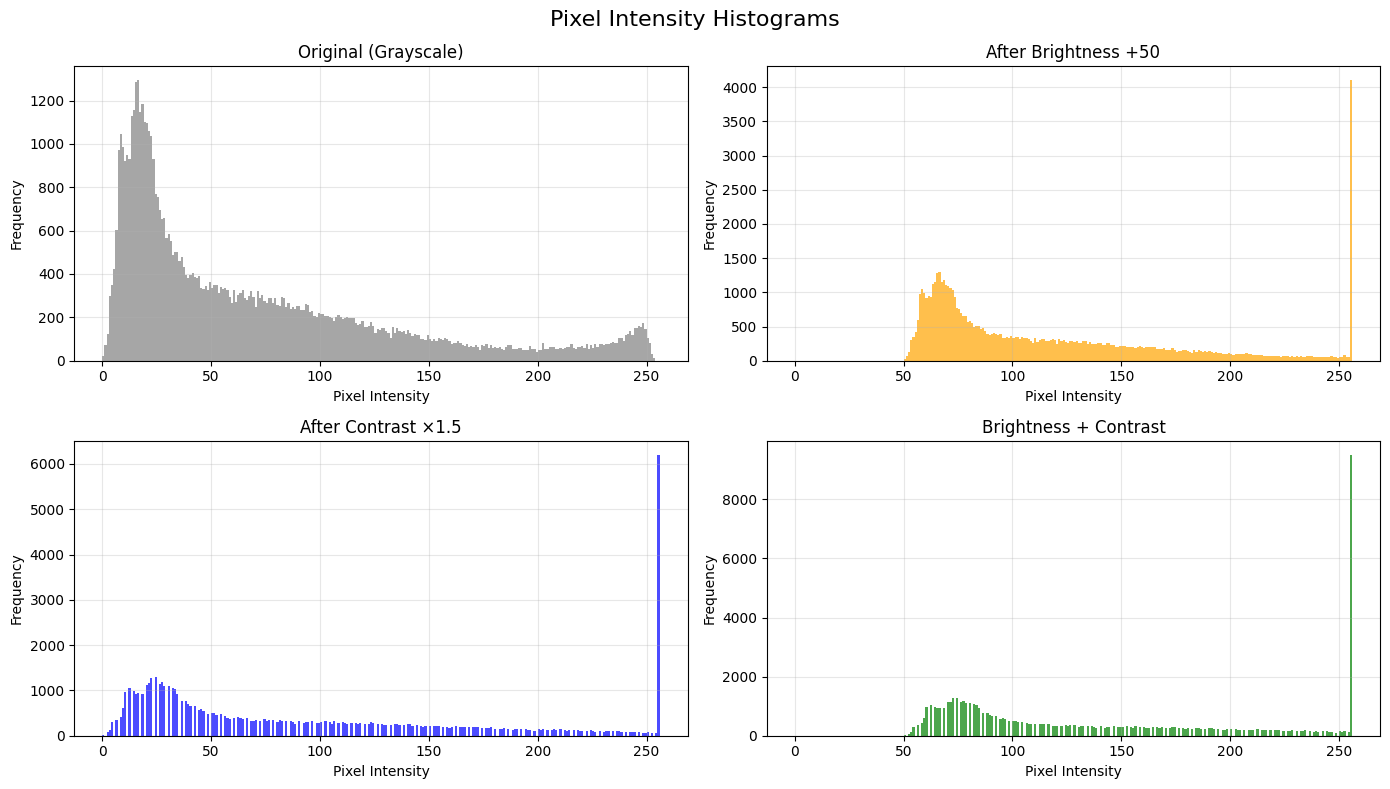

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

images  = [img_gray, bright, contrast, both]
titles  = ["Original (Grayscale)", "After Brightness +50",
           "After Contrast ×1.5",  "Brightness + Contrast"]
colors  = ["gray", "orange", "blue", "green"]

for ax, image, title, color in zip(axes.flatten(), images, titles, colors):
    ax.hist(image.ravel(), bins=256, range=(0, 256), color=color, alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

plt.suptitle("Pixel Intensity Histograms", fontsize=16)
plt.tight_layout()
plt.show()

# Image Resolution & Pixel Statistics

In [ ]:

height, width, channels = img.shape

print("=" * 40)
print("📊 Image Information")
print("=" * 40)
print(f"✅ Resolution  : {width} × {height} pixels")
print(f"✅ Channels    : {channels} (RGB)")
print(f"✅ Bit Depth   : {img.dtype}")
print("\n📊 Pixel Intensity Statistics:")
print(f"  Min pixel value  : {img_gray.min()}")
print(f"  Max pixel value  : {img_gray.max()}")
print(f"  Mean brightness  : {img_gray.mean():.2f}")
print(f"  Std (contrast)   : {img_gray.std():.2f}")
print("=" * 40)

📊 Image Information
✅ Resolution  : 250 × 250 pixels
✅ Channels    : 3 (RGB)
✅ Bit Depth   : uint8

📊 Pixel Intensity Statistics:
  Min pixel value  : 0
  Max pixel value  : 254
  Mean brightness  : 69.11
  Std (contrast)   : 64.10


#Visualize Sample Batch

Found 10798 images belonging to 1 classes.
Found 10798 images belonging to 1 classes.


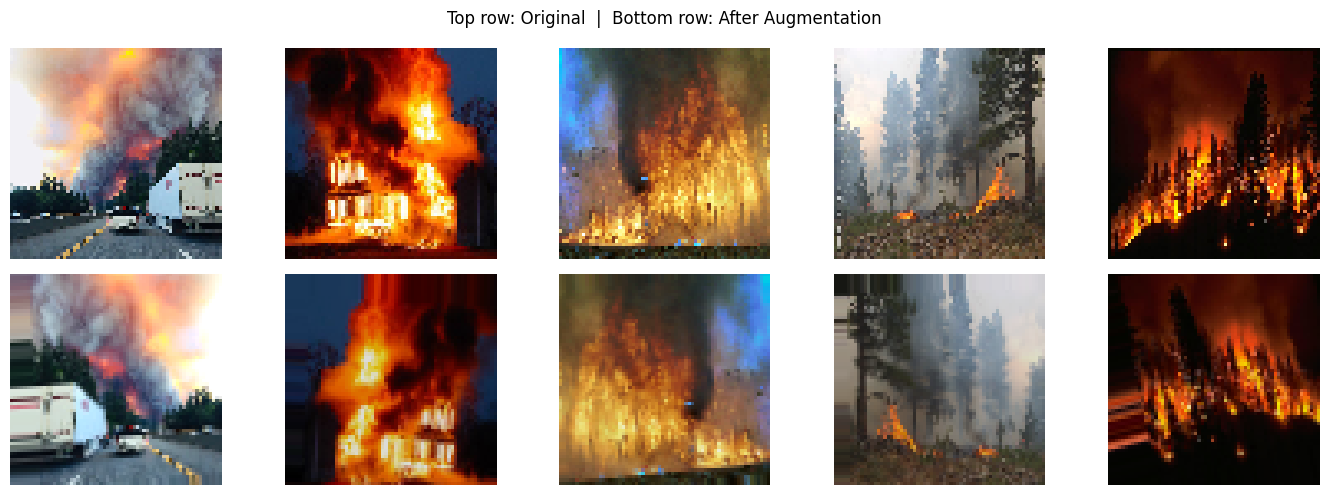

In [ ]:
# Show the same image before and after augmentation
sample_datagen_no_aug = ImageDataGenerator(rescale=1.0/255)
sample_datagen_aug    = ImageDataGenerator(
    rescale=1.0/255, rotation_range=15,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

sample_gen_orig = sample_datagen_no_aug.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=5, classes=["fire"], shuffle=False
)
sample_gen_aug = sample_datagen_aug.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=5, classes=["fire"], shuffle=False, seed=42
)

orig_imgs, _ = next(sample_gen_orig)
aug_imgs,  _ = next(sample_gen_aug)

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle("Top row: Original  |  Bottom row: After Augmentation", fontsize=12)
for i in range(5):
    axes[0, i].imshow(orig_imgs[i]); axes[0, i].axis('off')
    axes[1, i].imshow(aug_imgs[i]);  axes[1, i].axis('off')
plt.tight_layout()
plt.show()

# Model A: Simple CNN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense,
    BatchNormalization,
    Dropout
)

def build_light_cnn():

    model = Sequential([

        Conv2D(16, (3,3),
               activation='relu',
               padding='same',
               input_shape=(IMG_SIZE, IMG_SIZE, 3)),

        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(32, (3,3),
               activation='relu',
               padding='same'),

        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3),
               activation='relu',
               padding='same'),

        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(64, activation='relu'),

        Dropout(0.3),

        Dense(3, activation='softmax')
    ])

    return model

# Train CNN

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Build model
cnn_model = build_light_cnn()

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
cnn_model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("Training Simple CNN ...\n")

t0 = time.time()

# Train model
history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining time: {(time.time()-t0)/60:.1f} min")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,435 (1.09 MB)

 Trainable params: 286,211 (1.09 MB)

 Non-trainable params: 224 (896.00 B)

Training Simple CNN ...

Epoch 1/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 473s 542ms/step - accuracy: 0.8810 - loss: 0.3522 - val_accuracy: 0.8759 - val_loss: 0.3435
Epoch 2/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 449s 521ms/step - accuracy: 0.9187 - loss: 0.2440 - val_accuracy: 0.8652 - val_loss: 0.4571
Epoch 3/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 486s 502ms/step - accuracy: 0.9306 - loss: 0.2126 - val_accuracy: 0.9092 - val_loss: 0.2733
Epoch 4/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 478s 555ms/step - accuracy: 0.9383 - loss: 0.1928 - val_accuracy: 0.9204 - val_loss: 0.2343
Epoch 5/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 442s 512ms/step - accuracy: 0.9427 - loss: 0.1712 - val_accuracy: 0.8664 - val_loss: 0.4994
Epoch 6/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 437s 507ms/step - accuracy: 0.9473 - loss: 0.1615 - val_accuracy: 0.9315 - val_loss: 0.2614
Epoch 7/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 449s 522ms/step - accuracy: 0.9481 - loss: 0.1618 - val_accuracy: 0.9339 - val_loss: 0.1996
Epoch 8/10
861/861 ━━━━━━━━━━━━━━━━━━━━ 435s 505ms/

# Evaluate CNN

Test Accuracy: 93.42%  |  Test Loss: 0.1904


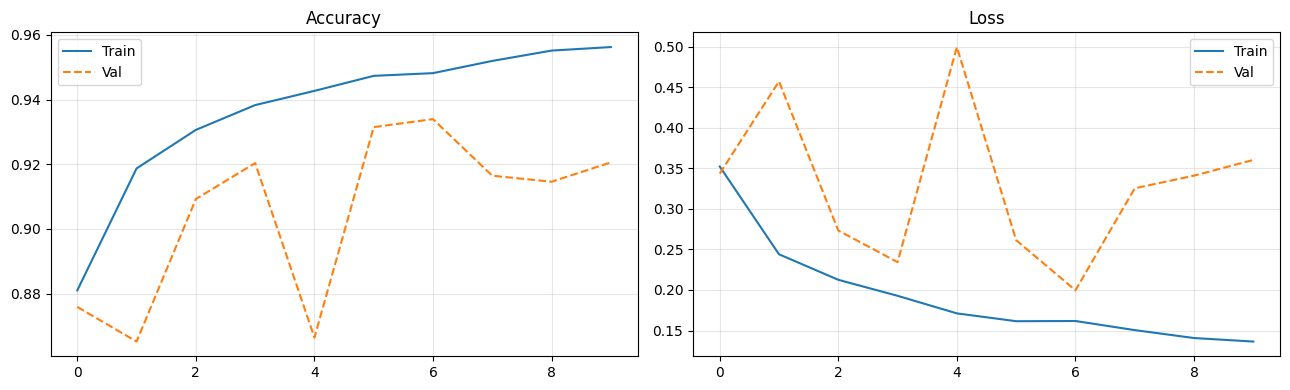

              precision    recall  f1-score   support

        fire       0.97      0.95      0.96      3500
    non fire       0.87      0.97      0.91      3500
       Smoke       0.98      0.88      0.93      3500

    accuracy                           0.93     10500
   macro avg       0.94      0.93      0.93     10500
weighted avg       0.94      0.93      0.93     10500



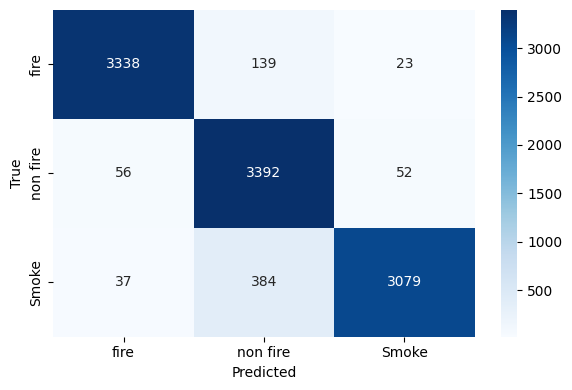

In [ ]:
test_gen.reset()
loss, acc = cnn_model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%  |  Test Loss: {loss:.4f}")

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val', linestyle='--')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val', linestyle='--')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Classification report + confusion matrix
test_gen.reset() #why?
y_pred = np.argmax(cnn_model.predict(test_gen, verbose=0), axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

#Model B: Transfer Learning with MobileNetV2 (ImageNet)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
base_model.trainable = False

tl_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
])

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# train Transfer Learning with MobileNetV2 (ImageNet)

In [ ]:


# 1. Unfreeze the base model
base_model.trainable = True

# 2. Freeze all layers except last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. Compile the model AFTER changing trainable layers
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train (use your existing generators)
history_finetune = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)



Epoch 1/5
861/861 ━━━━━━━━━━━━━━━━━━━━ 497s 557ms/step - accuracy: 0.6841 - loss: 0.7865 - val_accuracy: 0.8465 - val_loss: 0.4334
Epoch 2/5
861/861 ━━━━━━━━━━━━━━━━━━━━ 453s 526ms/step - accuracy: 0.8401 - loss: 0.4291 - val_accuracy: 0.8981 - val_loss: 0.2872
Epoch 3/5
861/861 ━━━━━━━━━━━━━━━━━━━━ 443s 514ms/step - accuracy: 0.8714 - loss: 0.3458 - val_accuracy: 0.9125 - val_loss: 0.2496
Epoch 4/5
861/861 ━━━━━━━━━━━━━━━━━━━━ 509s 522ms/step - accuracy: 0.8900 - loss: 0.3048 - val_accuracy: 0.9162 - val_loss: 0.2389
Epoch 5/5
861/861 ━━━━━━━━━━━━━━━━━━━━ 447s 519ms/step - accuracy: 0.9003 - loss: 0.2722 - val_accuracy: 0.9234 - val_loss: 0.2319


# **Generate Predictions for MobileNetV2**

In [ ]:
# Generate predictions and predicted classes
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


test_gen.reset()

pred_probs_tl = tl_model.predict(test_gen)
pred_classes_tl = np.argmax(pred_probs_tl, axis=1)

true_classes = test_gen.classes
class_names = list(test_gen.class_indices.keys())

329/329 ━━━━━━━━━━━━━━━━━━━━ 140s 414ms/step


## Classification Report for MobileNetV2

In [ ]:
# Print Precision, Recall, F1-Score and Accuracy

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_tl  = accuracy_score(true_classes, pred_classes_tl)
precision_tl = precision_score(true_classes, pred_classes_tl, average='weighted')
recall_tl    = recall_score(true_classes, pred_classes_tl, average='weighted')
f1_tl        = f1_score(true_classes, pred_classes_tl, average='weighted')

print("=" * 50)
print("MobileNetV2 Evaluation Metrics")
print("=" * 50)

print(f"Accuracy : {accuracy_tl:.4f}")
print(f"Precision: {precision_tl:.4f}")
print(f"Recall   : {recall_tl:.4f}")
print(f"F1-Score : {f1_tl:.4f}")

print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes_tl, target_names=class_names))

MobileNetV2 Evaluation Metrics
Accuracy : 0.9079
Precision: 0.9105
Recall   : 0.9079
F1-Score : 0.9079

Classification Report:

              precision    recall  f1-score   support

        fire       0.94      0.93      0.93      3500
    non fire       0.86      0.94      0.90      3500
       Smoke       0.94      0.86      0.90      3500

    accuracy                           0.91     10500
   macro avg       0.91      0.91      0.91     10500
weighted avg       0.91      0.91      0.91     10500



# **Confusion Matrix Heatmap**

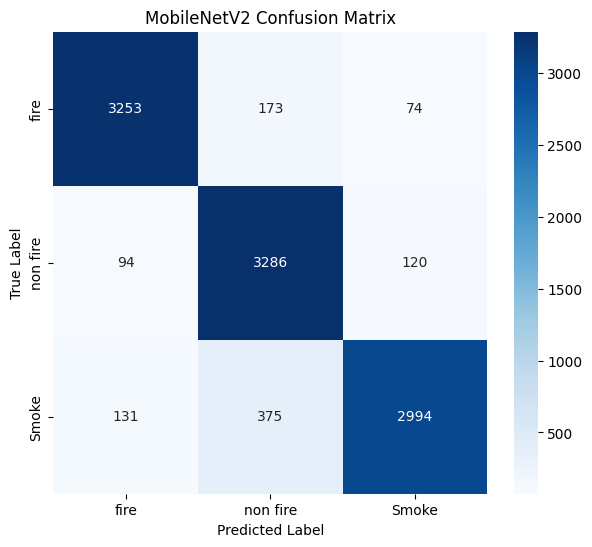

In [ ]:
# Visualize confusion matrix using heatmap

import seaborn as sns

cm_tl = confusion_matrix(true_classes, pred_classes_tl)

plt.figure(figsize=(7,6))
sns.heatmap(cm_tl,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('MobileNetV2 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Plot Transfer Learning Training Curves**

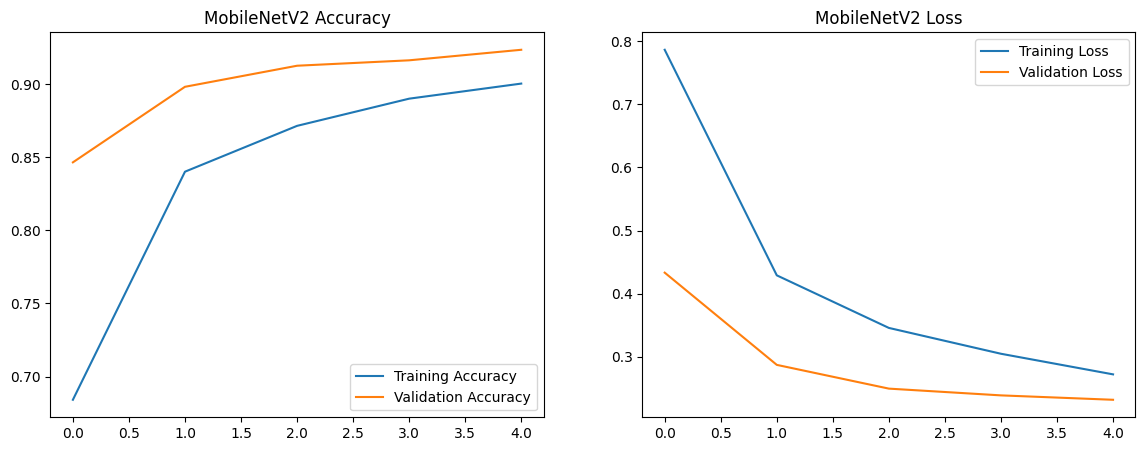

In [ ]:
# Plot training and validation accuracy/loss

acc      = history_finetune.history['accuracy']
val_acc  = history_finetune.history['val_accuracy']
loss     = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('MobileNetV2 Accuracy')

# Loss Plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('MobileNetV2 Loss')

plt.show()

# **Predict on New Images**

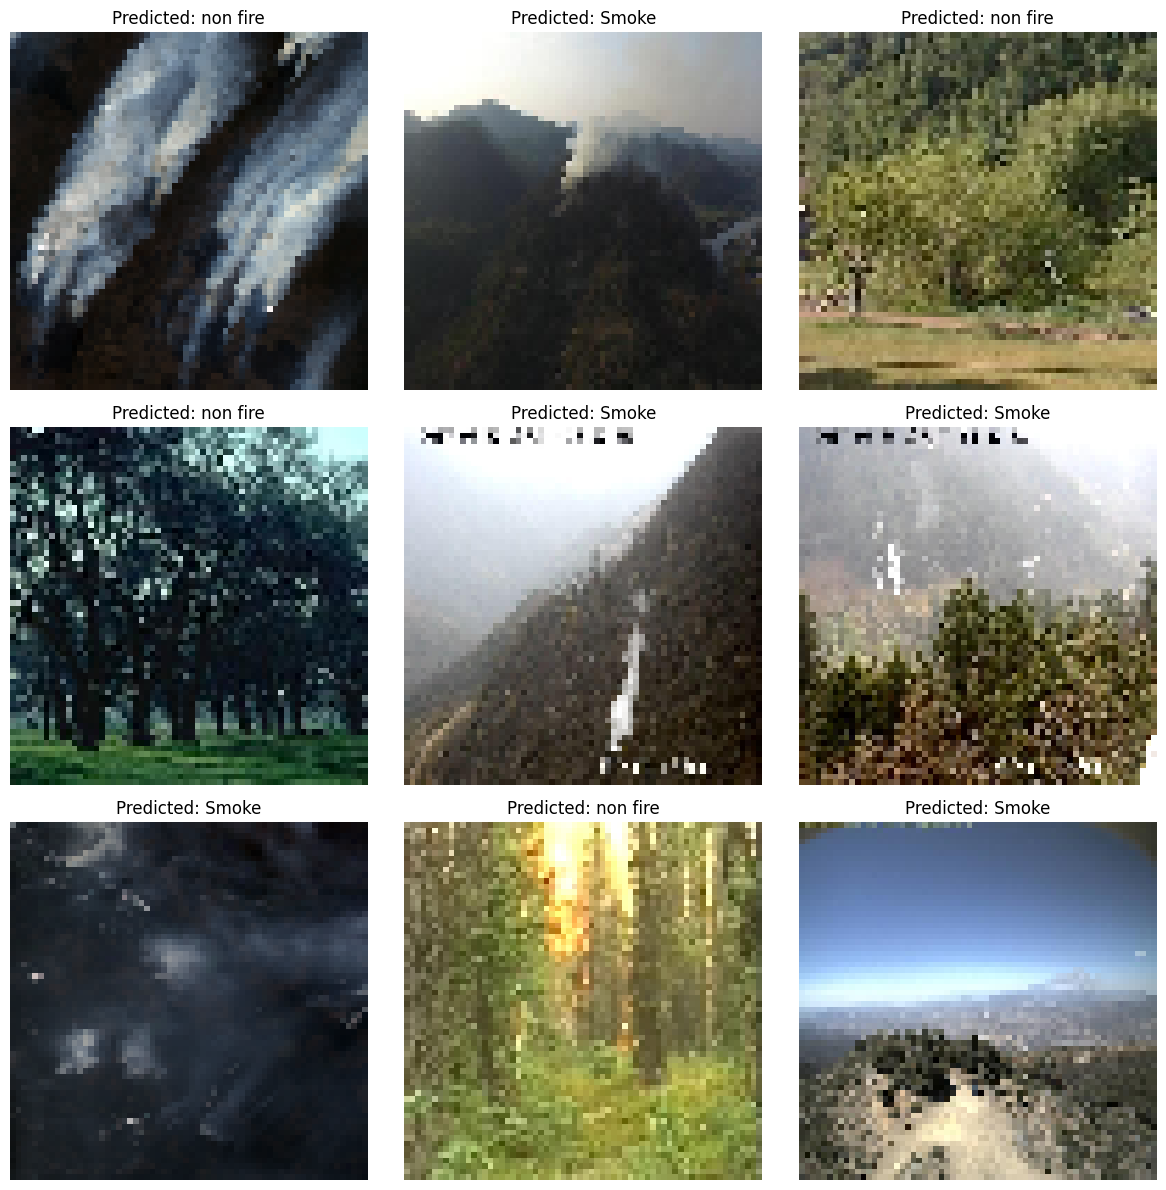

In [ ]:
# Predict random images from test dataset

import random
from tensorflow.keras.preprocessing import image

random_images = random.sample(list(TEST_DIR.rglob('*.*')), 9)

plt.figure(figsize=(12,12))

for i, img_path in enumerate(random_images):

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
# Classification not prediction
    prediction = tl_model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Visualize Correct vs Wrong **Predictions**

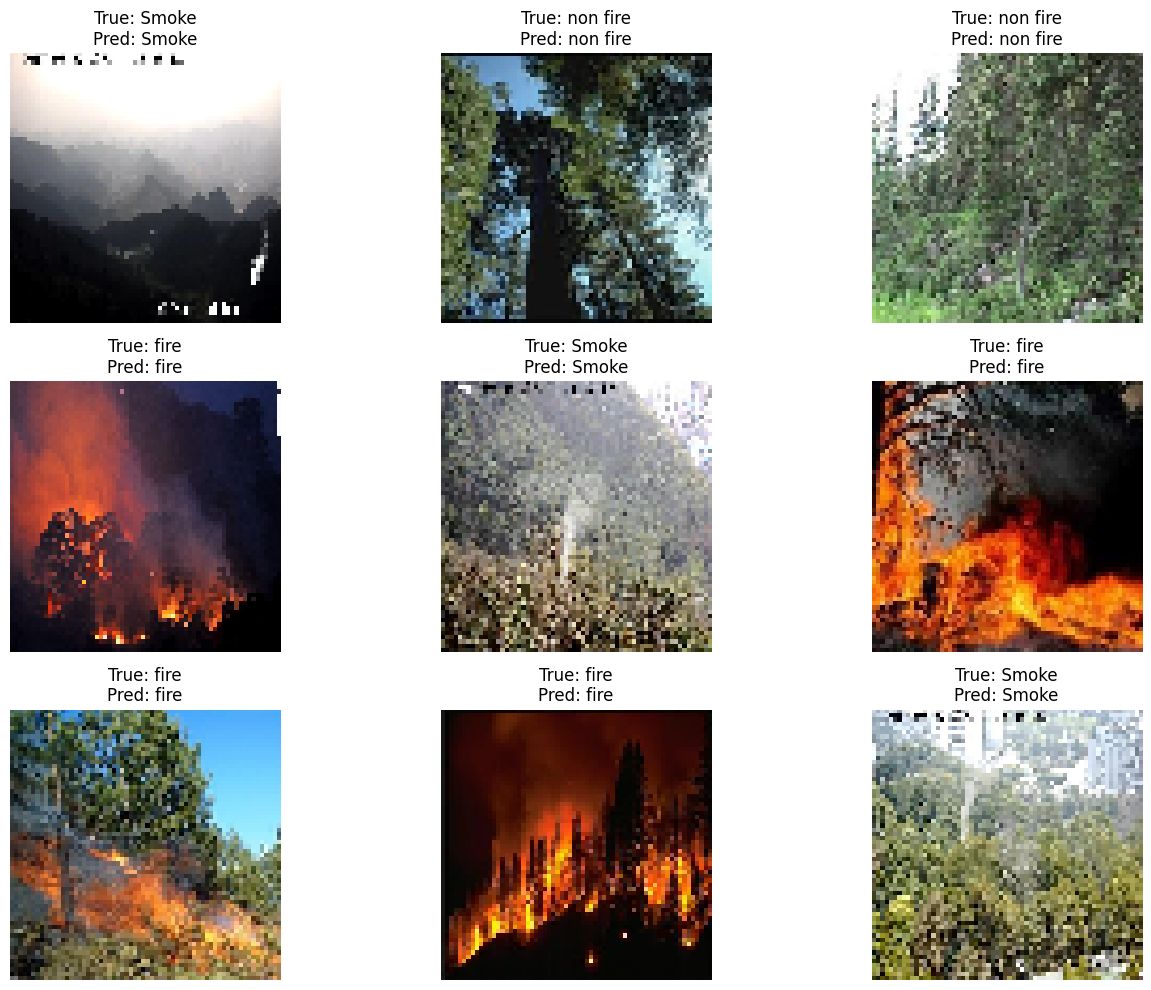

In [ ]:
# Show prediction results with true labels

plt.figure(figsize=(14,10))

sample_indices = np.random.choice(len(test_gen.filenames), 9, replace=False)

for i, idx in enumerate(sample_indices):

    img_path = os.path.join(TEST_DIR, test_gen.filenames[idx])

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = tl_model.predict(img_array, verbose=0)
    pred_label = class_names[np.argmax(pred)]

    true_label = test_gen.filenames[idx].split('/')[0]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Count Trainable Parameters for Both Models**

In [ ]:
# Compare number of trainable parameters

cnn_params = cnn_model.count_params()
tl_params  = tl_model.count_params()

print("=" * 50)
print("Trainable Parameters Comparison")
print("=" * 50)

print(f"CNN From Scratch Parameters : {cnn_params:,}")
print(f"MobileNetV2 Parameters      : {tl_params:,}")

Trainable Parameters Comparison
CNN From Scratch Parameters : 286,435
MobileNetV2 Parameters      : 2,422,339


# Compare CNN vs **MobileNetV2**

In [ ]:
# Create comparison table between both models
import pandas as pd
cnn_loss, cnn_acc = cnn_model.evaluate(test_gen, verbose=0)

comparison_results = {
    'Model': ['CNN From Scratch', 'MobileNetV2'],

    'Accuracy': [
        round(cnn_acc, 4),
        round(accuracy_tl, 4)
    ],

    'Precision': [
        round(precision_score(true_classes,
                              np.argmax(cnn_model.predict(test_gen), axis=1),
                              average='weighted'), 4),

        round(precision_tl, 4)
    ],

    'Recall': [
        round(recall_score(true_classes,
                           np.argmax(cnn_model.predict(test_gen), axis=1),
                           average='weighted'), 4),

        round(recall_tl, 4)
    ],

    'F1-Score': [
        round(f1_score(true_classes,
                       np.argmax(cnn_model.predict(test_gen), axis=1),
                       average='weighted'), 4),

        round(f1_tl, 4)
    ],

    'Parameters': [cnn_params, tl_params]
}

comparison_df = pd.DataFrame(comparison_results)
comparison_df

329/329 ━━━━━━━━━━━━━━━━━━━━ 121s 368ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 118s 360ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 111s 336ms/step


,Model,Accuracy,Precision,Recall,F1-Score,Parameters
0,CNN From Scratch,0.9342,0.9385,0.9342,0.9345,286435
1,MobileNetV2,0.9079,0.9105,0.9079,0.9079,2422339


# Visualize Model **Comparison**

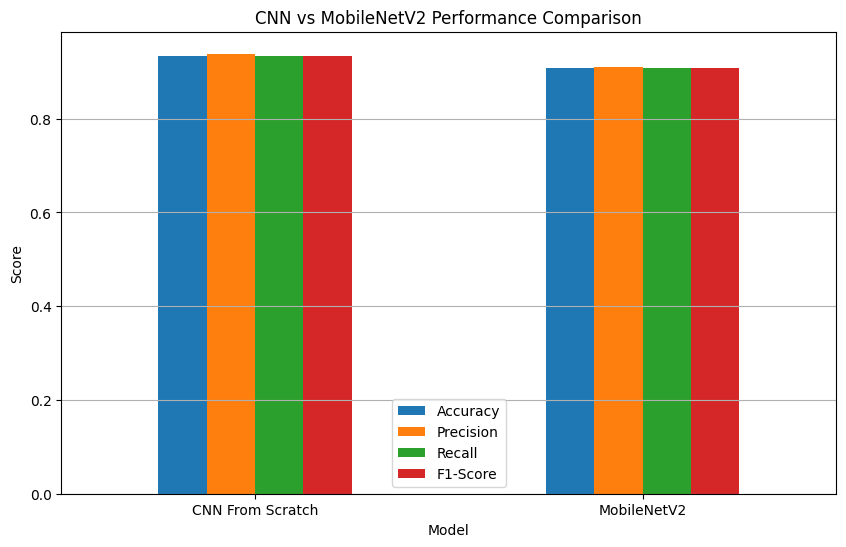

In [ ]:
# Plot comparison between CNN and MobileNetV2

comparison_df.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    kind='bar',
    figsize=(10,6)
)

plt.title('CNN vs MobileNetV2 Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# **Overfitting / Underfitting Analysis**

In [ ]:
# Analyze overfitting and underfitting

print("=" * 60)
print("Model Analysis")
print("=" * 60)

train_acc_final = history_finetune.history['accuracy'][-1]
val_acc_final   = history_finetune.history['val_accuracy'][-1]

print(f"Final Training Accuracy   : {train_acc_final:.4f}")
print(f"Final Validation Accuracy : {val_acc_final:.4f}")

if train_acc_final - val_acc_final > 0.10:
    print("\nThe model shows signs of OVERFITTING.")
    print("Training accuracy is much higher than validation accuracy.")

elif val_acc_final > train_acc_final:
    print("\nThe model may be UNDERFITTING.")
    print("Validation accuracy is higher than training accuracy.")

else:
    print("\nThe model is well balanced with good generalization.")

Model Analysis
Final Training Accuracy   : 0.9003
Final Validation Accuracy : 0.9234

The model may be UNDERFITTING.
Validation accuracy is higher than training accuracy.


# **Final Conclusion**

In [ ]:
# Final project conclusion

print("=" * 60)
print("Final Conclusion")
print("=" * 60)

print("This project implemented two deep learning models for forest fire image classification.")

print("\n1. CNN From Scratch:")
print("   - Built manually layer-by-layer")
print("   - Achieved good classification performance")
print("   - Required more training effort")

print("\n2. MobileNetV2 Transfer Learning:")
print("   - Used pre-trained ImageNet weights")
print("   - Achieved higher accuracy and better generalization")
print("   - Reduced training time significantly")

print("\n3. Preprocessing and augmentation improved overall performance")
print("   and reduced overfitting.")

print("\n4. Transfer Learning achieved the best final performance")
print("   for the forest fire classification task.")

Final Conclusion
This project implemented two deep learning models for forest fire image classification.

1. CNN From Scratch:
   - Built manually layer-by-layer
   - Achieved good classification performance
   - Required more training effort

2. MobileNetV2 Transfer Learning:
   - Used pre-trained ImageNet weights
   - Achieved higher accuracy and better generalization
   - Reduced training time significantly

3. Preprocessing and augmentation improved overall performance
   and reduced overfitting.

4. Transfer Learning achieved the best final performance
   for the forest fire classification task.


# **Save Final Model**

In [ ]:
# Save trained Transfer Learning model

tl_model.save('mobilenetv2_forest_fire_model.h5')

print("Model saved successfully.")

Model saved successfully.


# **Save CNN Model**

In [ ]:
# Save CNN From Scratch model

cnn_model.save('cnn_forest_fire_model.h5')

print("CNN model saved successfully.")

CNN model saved successfully.
